In [3]:
import scvelo as scv
import scanpy as sc
import os
import glob
import loompy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
scv.settings.verbosity = 3  # show errors(0), warnings(1), info(2), hints(3)
scv.settings.presenter_view = True  # set max width size for presenter view
scv.set_figure_params('scvelo')  # for beautified visualization

In [2]:
# Base path where all captures are stored
base_dir = "/group/canc2/anson/working/cf-eti-bal/data/velocyto"

# List valid capture folders manually (excluding 'obsolete', 'log')
capture_dirs = [
    "BP1-c1", "BP1-c2", "BP1-c3",
    "BP2-c1", "BP2-c2", "BP2-c3",
    "Pi1-c1", "Pi1-c2",
    "capture1-1", "capture1-2", "capture1-3", "capture1-4"
]

# Dictionary to store loom connections
loom_data = {}

# Loop through folders and load the loom files
for capture in capture_dirs:
    loom_path = os.path.join(base_dir, capture)
    loom_files = glob.glob(os.path.join(loom_path, "*.loom"))
    
    if not loom_files:
        print(f"No loom file found in {capture}")
        continue
    
    if len(loom_files) > 1:
        print(f"Multiple loom files found in {capture}, using the first one.")

    loom_file = loom_files[0]
    ds = loompy.connect(loom_file, mode='r')
    
    # Store it
    loom_data[capture] = ds
    
    # Print summary
    print(f"{capture}: {ds.shape[1]} cells, {ds.shape[0]} genes")

BP1-c1: 20195 cells, 36601 genes
BP1-c2: 15566 cells, 36601 genes
BP1-c3: 17252 cells, 36601 genes
BP2-c1: 26947 cells, 36601 genes
BP2-c2: 18987 cells, 36601 genes
BP2-c3: 19589 cells, 36601 genes
Pi1-c1: 23526 cells, 36601 genes
Pi1-c2: 22808 cells, 36601 genes
capture1-1: 28490 cells, 36601 genes
capture1-2: 27739 cells, 36601 genes
capture1-3: 28763 cells, 36601 genes
capture1-4: 28370 cells, 36601 genes


In [3]:
ds = loom_data["BP1-c1"]
print(ds.shape)                # genes × cells
print(ds.ca.keys())           # column attributes
print(ds.ra.keys())           # row attributes
print(ds.layers.keys())       # ['spliced', 'unspliced', 'ambiguous']

print(ds.ca["CellID"][:5])    # cell barcodes, to match to your Seurat/Scanpy object

# e.g., sparse matrices (rows = genes, columns = cells)
spliced = ds.layers["spliced"]
unspliced = ds.layers["unspliced"]
ambiguous = ds.layers["ambiguous"]

print(spliced.shape)  # should match ds.shape

(36601, 20195)
['CellID']
['Accession', 'Chromosome', 'End', 'Gene', 'Start', 'Strand']
['', 'ambiguous', 'spliced', 'unspliced']
[np.str_('sample_alignments_40G1Z:AAACCCAAGCCATTCAx')
 np.str_('sample_alignments_40G1Z:AAAGAACGTCTTGGTAx')
 np.str_('sample_alignments_40G1Z:AAACGAAGTCAGCGTCx')
 np.str_('sample_alignments_40G1Z:AAACGAATCACGGGAAx')
 np.str_('sample_alignments_40G1Z:AAACCCAGTGTGGTCCx')]
(36601, 20195)


In [4]:
out = "/group/canc2/anson/working/cf-eti-bal/data/SCEs/analysis/RecM_velo.adata.h5ad"
file = "/group/canc2/anson/working/cf-eti-bal/data/SCEs/analysis/RecM.h5ad"

if os.path.exists(out):
    adata = sc.read_h5ad(out)
else:
    adata = sc.read_h5ad(file)# check layers
print(adata)
print("layers:", adata.layers.keys())

AnnData object with n_obs × n_vars = 17584 × 2821
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Barcode', 'Capture', 'HTODemux.ID', 'HTODemux_result.orig.ident', 'HTODemux_result.nCount_RNA', 'HTODemux_result.nFeature_RNA', 'HTODemux_result.nCount_HTO', 'HTODemux_result.nFeature_HTO', 'HTODemux_result.HTO_maxID', 'HTODemux_result.HTO_secondID', 'HTODemux_result.HTO_margin', 'HTODemux_result.HTO_classification', 'HTODemux_result.HTO_classification.global', 'HTODemux_result.hash.ID', 'sampleID.HTO', 'colours.hto_colours', 'colours.sample_colours', 'colours.capture_colours', 'colours.genetic_donor_colours', 'colours.sampleID.HTO_colours', 'colours.sampleID.genetics_colours', 'vireo.donor_id', 'vireo.prob_max', 'vireo.prob_doublet', 'vireo.n_vars', 'vireo.best_singlet', 'vireo.best_doublet', 'vireo.doublet_logLikRatio', 'genetic_donor', 'sampleID.genetics', 'sampleID', 'Age', 'Sex', 'Condition', 'Bronchiectasis', 'sum', 'detected', 'subsets_Mito_sum', 'subsets_Mito_detected', 'subs

In [172]:
# 1. Create empty matrices for spliced, unspliced, ambiguous
gene_names = loom_data["BP1-c1"].ra["Gene"][:]
adata_genes = adata.var_names

# Ensure matching gene order (filter + reorder)
common_genes = np.intersect1d(gene_names, adata_genes)
print(f"Number of common genes: {len(common_genes)}")

# Sort loom gene indices and reorder common_genes accordingly
loom_gene_idx = [np.where(gene_names == g)[0][0] for g in common_genes]
loom_gene_idx_sorted = np.argsort(loom_gene_idx)
loom_gene_idx_sorted_vals = np.array(loom_gene_idx)[loom_gene_idx_sorted]
common_genes_sorted = np.array(common_genes)[loom_gene_idx_sorted]

# Reorder adata to match sorted gene order
adata = adata[:, common_genes_sorted]

# Create empty sparse matrices to hold layers
n_cells = adata.n_obs
n_genes = len(common_genes_sorted)

spliced_mat    = csr_matrix((n_cells, n_genes))
unspliced_mat  = csr_matrix((n_cells, n_genes))
ambiguous_mat  = csr_matrix((n_cells, n_genes))

# Helper: build a dict mapping Barcode+Capture to adata index
adata_obs_key = adata.obs["Barcode"].astype(str) + "-" + adata.obs["Capture"].astype(str)
barcode_to_idx = dict(zip(adata_obs_key.values, range(len(adata_obs_key))))

# 2. Iterate over all loom files
for capture, ds in loom_data.items():
    cell_barcodes = [x.split(":")[-1].replace("x", "-1") for x in ds.ca["CellID"]]  # clean to match adata
    full_ids = [bc + "-" + capture for bc in cell_barcodes]
    
    # Find overlap with adata
    matched = [(i, barcode_to_idx[full_id]) for i, full_id in enumerate(full_ids) if full_id in barcode_to_idx]
    print(f"{capture}: matched {len(matched)} cells")

    if not matched:
        ds.close()
        continue

    loom_idx, adata_idx = zip(*matched)

    # Pull and insert velocity matrices (spliced, etc.)
    spliced_mat[adata_idx, :] = csr_matrix(
        ds.layers["spliced"][loom_gene_idx_sorted_vals, :][:, loom_idx].T
    )
    unspliced_mat[adata_idx, :] = csr_matrix(
        ds.layers["unspliced"][loom_gene_idx_sorted_vals, :][:, loom_idx].T
    )
    ambiguous_mat[adata_idx, :] = csr_matrix(
        ds.layers["ambiguous"][loom_gene_idx_sorted_vals, :][:, loom_idx].T
    )

    ds.close()

adata.layers["spliced"]    = spliced_mat
adata.layers["unspliced"]  = unspliced_mat
adata.layers["ambiguous"]  = ambiguous_mat

Number of common genes: 25796
BP1-c1: matched 2149 cells
BP1-c2: matched 1838 cells
BP1-c3: matched 2067 cells
BP2-c1: matched 1341 cells
BP2-c2: matched 1260 cells
BP2-c3: matched 1380 cells
Pi1-c1: matched 234 cells
Pi1-c2: matched 228 cells
capture1-1: matched 1653 cells
capture1-2: matched 1736 cells
capture1-3: matched 1788 cells
capture1-4: matched 1777 cells


In [175]:
# Preprocess & normalize
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=3000)

# Compute moments
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)

# Estimate RNA velocity
scv.tl.recover_dynamics(adata, n_jobs=16)
scv.tl.velocity(adata, mode="dynamical")
scv.tl.velocity_graph(adata)
scv.tl.velocity_confidence(adata)
scv.tl.latent_time(adata)

Filtered out 179 genes that are detected 20 counts (shared).
Skip filtering by dispersion since number of variables are less than `n_top_genes`.
Logarithmized X.
computing moments based on connectivities


/home/anson.wong/.local/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


    finished (0:00:04) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
recovering dynamics (using 16/32 cores)


  0%|          | 0/784 [00:00<?, ?gene/s]

    finished (0:01:28) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:08) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/32 cores)


  0%|          | 0/17584 [00:00<?, ?cells/s]

    finished (0:00:35) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:03) --> added 
    'latent_time', shared time (adata.obs)


In [176]:
# save h5ad here
# Define save path
save_dir = "/group/canc2/anson/working/cf-eti-bal/data/SCEs/analysis/"

# Save full AnnData object
adata.write(f"{save_dir}RecM_velo.adata.h5ad")


In [13]:
# Create fixed-size figure
fig, ax = plt.subplots(figsize=(3, 3.5))

scv.pl.scatter(
    adata,
    basis="umap",
    color="velocity_length",
    cmap="inferno",
    size=10,
    alpha=0.8,
    title="Velocity Length",
    ax=ax,
    show=False
)
plt.tight_layout()
plt.savefig("RecM_velo_length.jpeg", dpi=3200, format="jpeg")
plt.close()

In [5]:
subtype_colours = {
    "Mono": "#f2cc8f",
    "MDM-IV": "#7209b7",
    "MDM-FABP4lo": "#83c5be",
    "MDM-FABP4hi": "#3a6ea5",
    "MDM-inflam": "#9e2a2b",
    "MDM-PLA2G7hi": "#9c6644",
    "IM": "#9a8c98"
}


In [6]:
# Subset based on magnitude
adata_high = adata[adata.obs["velocity_confidence"] > 0.5].copy()
scv.pp.neighbors(adata_high, n_pcs=30, n_neighbors=30)
scv.tl.velocity_graph(adata_high,n_jobs=12)

computing neighbors
    finished (0:00:30) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 12/32 cores)


  0%|          | 0/17296 [00:00<?, ?cells/s]

    finished (0:00:21) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


Stream velocity graph

In [14]:
# Set up figure size
fig, ax = plt.subplots(figsize=(3, 3.5))

# Plot streamlines with black arrows
scv.pl.velocity_embedding_stream(
    adata_high,
    basis="umap",
    color="subtype",                   # color points by subtype
    palette=subtype_colours,
    legend_loc="none",
    title="",
    size=10,                            # cell dot size
    alpha=0.3,                         # cell transparency
    arrow_size=1.2,                    # arrowhead size
    linewidth=1.2,                     # streamline width
    smooth=0.5,                        # streamline smoothness (0–1)
    density=2,                       # streamline density (try 0.8–2.0)
    color_map=None,                    # no arrow coloring
    ax=ax,
    show=False
)

# Save at high resolution
plt.tight_layout()
plt.savefig("RecM_velocity_stream.jpeg", dpi=3200, format="jpeg")
plt.close()

In [7]:
# Create fixed-size figure
fig, ax = plt.subplots(figsize=(3, 3.5))

# Plot stream with more density
scv.pl.velocity_embedding(
    adata_high,
    basis="umap",
    color="subtype",
    palette=subtype_colours,
    legend_loc="right margin",
    title="",
    size=5,              # reduce point size to help arrows show
    alpha=0.5,
    arrow_size=2.5,      # make arrows more visible
    arrow_length=20.0,    # increase arrow shaft
    linewidth=0.6,
    density=0.02,
    ax=ax,
    show=False
)

# Show it manually
plt.tight_layout()
plt.savefig("RecM_velocity.jpeg", dpi=1600, format="jpeg")
plt.close()

computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


In [12]:
# Create fixed-size figure
fig, ax = plt.subplots(figsize=(3, 3.5))

scv.pl.scatter(adata, color=['latent_time'], cmap="viridis",basis='umap',ax=ax,show=False)

plt.tight_layout()
plt.savefig("RecM_latent_time.jpeg", dpi=3200, format="jpeg")
plt.close()

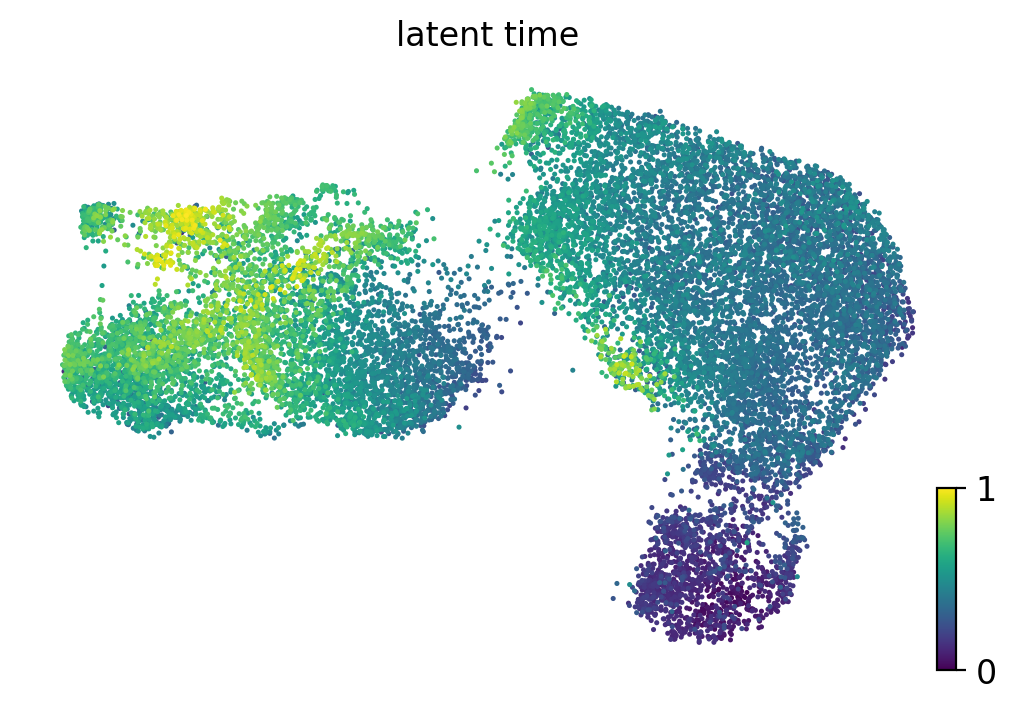